# Boston Marathon Analysis
Years available: 2018, 2019, 2021–2026 (2020 cancelled)

In [128]:
import glob
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
YEARS = [2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]

---
## 1 · Data Loading & Cleaning

In [129]:
def parse_time(s):
    """'HH:MM:SS' -> seconds as float. Returns NaN on bad input."""
    try:
        h, m, sec = str(s).split(":")
        return int(h) * 3600 + int(m) * 60 + int(sec)
    except Exception:
        return np.nan


def fmt_time(secs):
    """Seconds -> 'H:MM:SS' string for axis labels."""
    secs = int(secs)
    return f"{secs // 3600}:{(secs % 3600) // 60:02d}:{secs % 60:02d}"


frames = []
for yr in YEARS:
    try:
        df = pd.read_csv(f"results_{yr}.csv")
        df["year"] = yr
        frames.append(df)
    except Exception:
        pass

raw = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(raw):,} rows across {raw['year'].nunique()} years")

Loaded 202,211 rows across 8 years


In [130]:
# ── Deduplicate (last page of pagination overlaps) ──────────────────────────
raw = raw.drop_duplicates(subset=["year", "idp"]).reset_index(drop=True)

# ── Parse times ─────────────────────────────────────────────────────────────
raw["finish_secs"] = raw["finish_net"].apply(parse_time)
raw["half_secs"] = raw["half"].apply(parse_time)
raw["second_half"] = raw["finish_secs"] - raw["half_secs"]
raw["split_diff"] = raw["second_half"] - raw["half_secs"]  # + = positive split

# raw_full: everyone with a valid finish time (used for sub-3 counts / medians)
raw_full = raw.dropna(subset=["finish_secs"]).reset_index(drop=True)
# raw: only runners with both finish AND half split (used for split analysis)
raw = raw.dropna(subset=["finish_secs", "half_secs"]).reset_index(drop=True)
print(f"Split-analysis rows: {len(raw):,}  |  Full-field rows: {len(raw_full):,}")


Split-analysis rows: 200,820  |  Full-field rows: 202,211


In [131]:
# ── Infer gender ─────────────────────────────────────────────────────────────
# Within each (year, place_gender) group, sort by finish time.
#   rank 1 = Male, rank 2 = Female, rank 3+ = Para/adaptive (excluded).
# Solo-rank runners (no female counterpart) are in the male tail → Male.

for _r in [raw, raw_full]:
    _r["finish_rank_in_pg"] = (
        _r.groupby(["year", "place_gender"])["finish_secs"]
        .rank(method="first")
        .astype(int)
    )
    _r["gender"] = _r["finish_rank_in_pg"].map({1: "M", 2: "F"})

# df: split-analysis dataset (has split_diff)
df = raw[raw["gender"].notna()].copy()
# df_full: full field with valid finish times (no half-split requirement)
df_full = raw_full[raw_full["gender"].notna()].copy()

print(df_full.groupby(["year", "gender"]).size().unstack())


gender      F      M
year                
2018    11605  14145
2019    11973  14666
2021     7442   7942
2022    10567  14261
2023    11422  15177
2024    10924  14578
2025    12228  16105
2026    12587  16344


In [132]:
import string

# ── Infer age group ──────────────────────────────────────────────────────────
# Within each (year, gender, place_division), sort by finish time.
# Rank 1 = A (youngest/fastest), rank 2 = B, ..., rank 10 = J.
# Solo-rank runners with no division label are para athletes — excluded here.
df2 = df.copy()
df2["place_division"] = df2["place_division"].replace("–", np.nan)
df2 = df2.dropna(subset=["place_division"])
df2["place_division"] = df2["place_division"].astype(int)

df2["age_group"] = (
    df2.groupby(["year", "gender", "place_division"])["finish_secs"]
    .rank(method="first")
    .astype(int)
    .apply(lambda r: string.ascii_uppercase[r - 1] if r <= 26 else f"Z{r}")
)

print("Distinct age groups inferred per year/gender:")
print(df2.groupby(["year", "gender"])["age_group"].nunique().unstack())

Distinct age groups inferred per year/gender:
gender   F   M
year          
2018     9  11
2019    10  10
2021     9  10
2022    10  10
2023    10  10
2024    10  10
2025    10  10
2026    10  10


---
## 2 · Positive Split Magnitude vs. Finishing Time

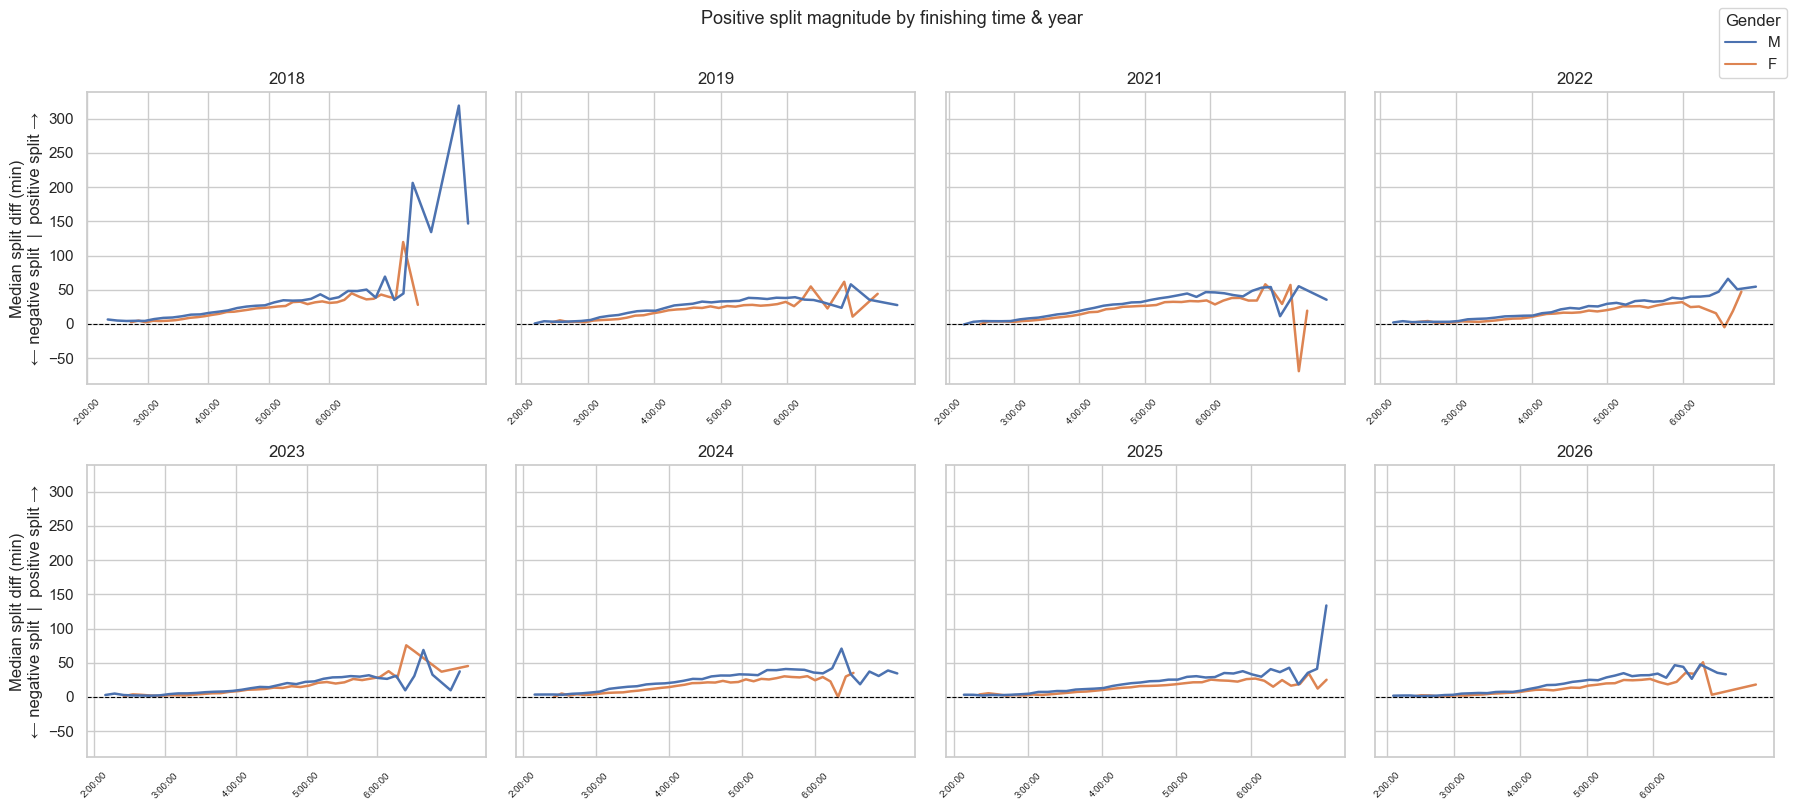

In [133]:
# One panel per year; M in blue, F in red.
# x = finish time, y = split_diff (seconds). Horizontal line at 0.

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()

palette = {"M": "#4C72B0", "F": "#DD8452"}

for ax, yr in zip(axes, YEARS):
    sub = df[df["year"] == yr]
    for g, gdf in sub.groupby("gender"):
        # Bin by finish time and take median split_diff per bin
        gdf = gdf.copy()
        gdf["finish_bin"] = pd.cut(gdf["finish_secs"], bins=40)
        binned = (
            gdf.groupby("finish_bin", observed=True)["split_diff"]
            .median()
            .reset_index()
        )
        binned["x"] = binned["finish_bin"].apply(lambda b: b.mid)
        ax.plot(
            binned["x"],
            binned["split_diff"] / 60,
            color=palette[g],
            label=g,
            linewidth=1.8,
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(str(yr), fontsize=12)
    ax.set_xlabel("")

    # x-axis: show H:MM labels
    ticks = np.arange(2 * 3600, 6.5 * 3600, 3600)
    ax.set_xticks(ticks)
    ax.set_xticklabels([fmt_time(t) for t in ticks], fontsize=7, rotation=45)

axes[0].set_ylabel("Median split diff (min)\n← negative split  |  positive split →")
axes[4].set_ylabel("Median split diff (min)\n← negative split  |  positive split →")
handles = [plt.Line2D([0], [0], color=c, label=l) for l, c in palette.items()]
fig.legend(handles=handles, loc="upper right", title="Gender")
fig.suptitle("Positive split magnitude by finishing time & year", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 3 · Negative-Split Rates Across Years

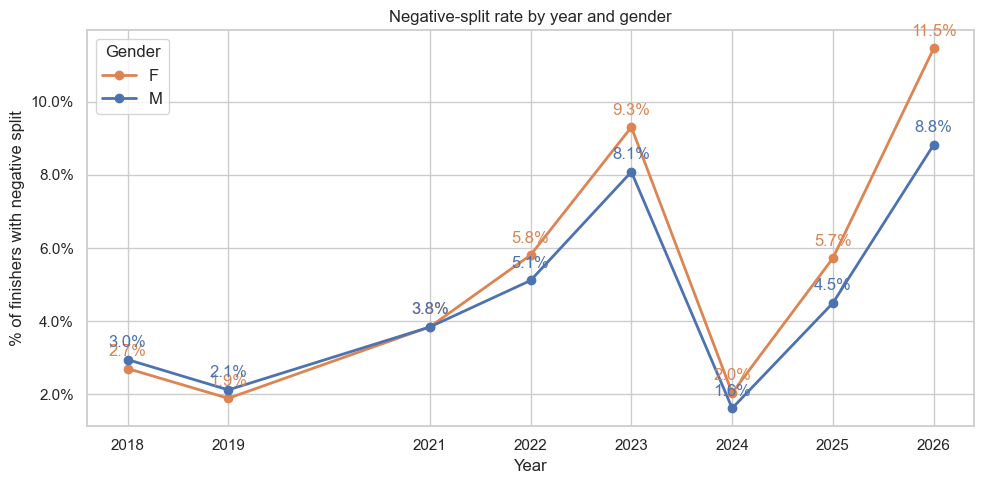

Overall negative-split rate (all years combined): 5.1%
  Men:   4.8%
  Women: 5.5%

gender     F    M
year             
2018     2.7  3.0
2019     1.9  2.1
2021     3.8  3.8
2022     5.8  5.1
2023     9.3  8.1
2024     2.0  1.6
2025     5.7  4.5
2026    11.5  8.8


/var/folders/hw/k51wqqw93751fx50t4_d520c0000gn/T/ipykernel_76674/1061337066.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_gender = df.groupby("gender").apply(


In [134]:
# A runner is a "negative splitter" if second_half < first_half (split_diff < 0).
# Small threshold: within 30 seconds is 'even'; outside is pos/neg.

THRESHOLD = 30  # seconds


def classify_split(d):
    if d < -THRESHOLD:
        return "negative"
    elif d > THRESHOLD:
        return "positive"
    else:
        return "even"


df["split_type"] = df["split_diff"].apply(classify_split)

rates = df.groupby(["year", "gender", "split_type"]).size().reset_index(name="n")
totals = df.groupby(["year", "gender"]).size().reset_index(name="total")
rates = rates.merge(totals, on=["year", "gender"])
rates["pct"] = rates["n"] / rates["total"] * 100

neg_rates = rates[rates["split_type"] == "negative"]

fig, ax = plt.subplots(figsize=(10, 5))
for g, gdf in neg_rates.groupby("gender"):
    ax.plot(gdf["year"], gdf["pct"], marker="o", label=g, color=palette[g], linewidth=2)
    for _, row in gdf.iterrows():
        ax.annotate(
            f"{row['pct']:.1f}%",
            (row["year"], row["pct"]),
            textcoords="offset points",
            xytext=(0, 9),
            ha="center",
            fontsize=12,
            color=palette[g],
        )

ax.set_xlabel("Year")
ax.set_ylabel("% of finishers with negative split")
ax.set_title("Negative-split rate by year and gender")
ax.set_xticks(YEARS)
ax.legend(title="Gender", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
plt.tight_layout()
plt.show()

# Overall negative-split rates across all years
overall_neg = (df["split_diff"] < -THRESHOLD).mean() * 100
by_gender = df.groupby("gender").apply(
    lambda g: (g["split_diff"] < -THRESHOLD).mean() * 100
)
print(f"Overall negative-split rate (all years combined): {overall_neg:.1f}%")
print(f"  Men:   {by_gender['M']:.1f}%")
print(f"  Women: {by_gender['F']:.1f}%")
print()
print(neg_rates.pivot(index="year", columns="gender", values="pct").round(1))


In [135]:
# Overall negative-split rates across all years
df26 = df[df["year"] == 2026]
overall_neg = (df26["split_diff"] < -THRESHOLD).mean() * 100
by_gender = df26.groupby("gender").apply(
    lambda g: (g["split_diff"] < -THRESHOLD).mean() * 100
)

print(f"Overall negative-split rate (all years combined): {overall_neg:.1f}%")
print(f"  Men:   {by_gender['M']:.1f}%")
print(f"  Women: {by_gender['F']:.1f}%")

Overall negative-split rate (all years combined): 10.0%
  Men:   8.8%
  Women: 11.5%


/var/folders/hw/k51wqqw93751fx50t4_d520c0000gn/T/ipykernel_76674/15745756.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_gender = df26.groupby("gender").apply(


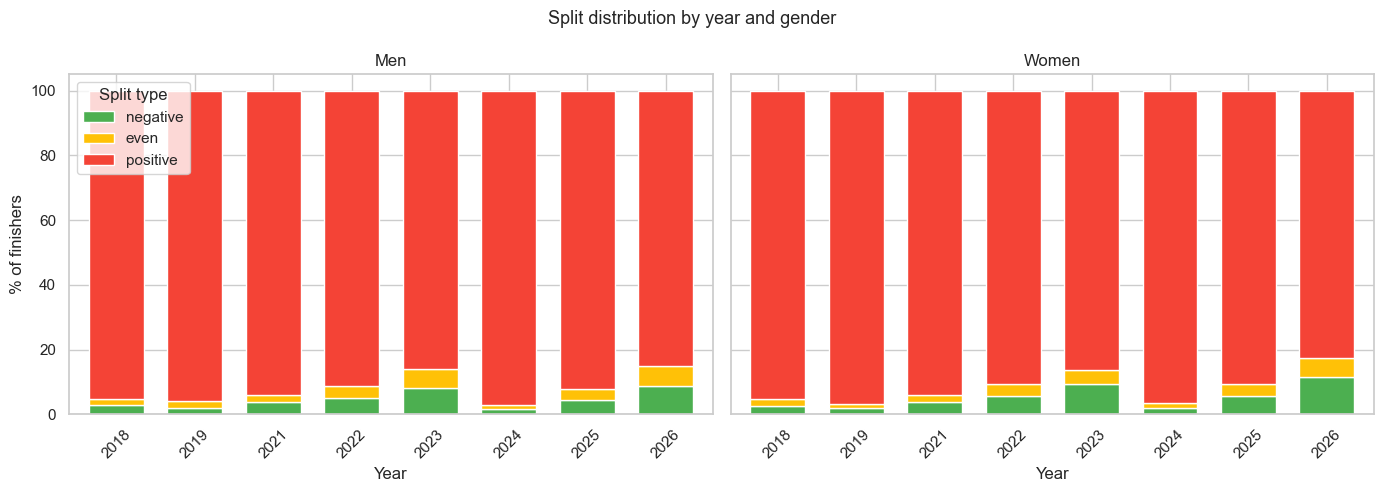

In [136]:
# Stacked bar: positive / even / negative share per year, by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
split_order = ["negative", "even", "positive"]
split_colors = ["#4CAF50", "#FFC107", "#F44336"]

for ax, g in zip(axes, ["M", "F"]):
    sub = (
        rates[rates["gender"] == g]
        .pivot(index="year", columns="split_type", values="pct")
        .reindex(columns=split_order, fill_value=0)
    )
    sub.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=split_colors,
        legend=(g == "M"),
        width=0.7,
    )
    ax.set_title(f"{'Men' if g == 'M' else 'Women'}")
    ax.set_xlabel("Year")
    ax.set_ylabel("% of finishers")
    ax.set_xticklabels(sub.index, rotation=45)

axes[0].legend(title="Split type", loc="upper left")
fig.suptitle("Split distribution by year and gender", fontsize=13)
plt.tight_layout()
plt.show()

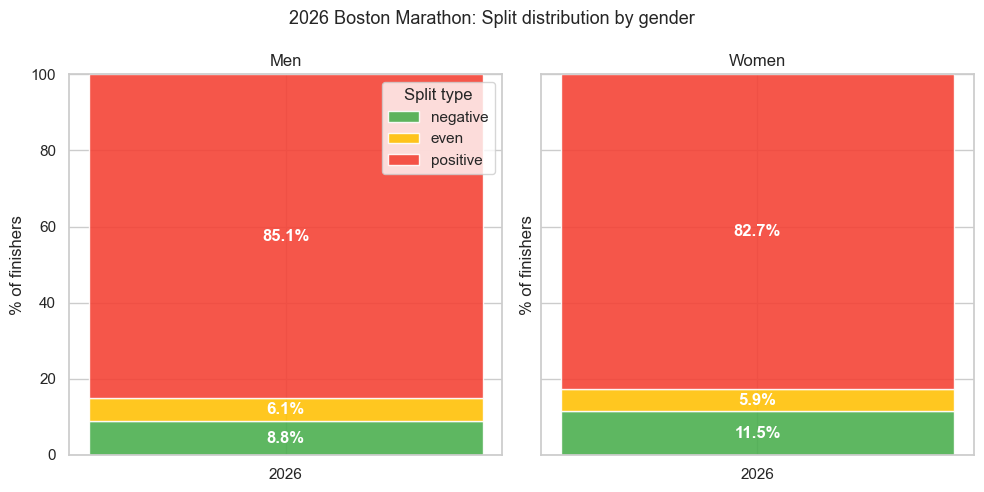

In [137]:
# 2026 Boston split distribution — single-year labeled bar chart
split_order = ["negative", "even", "positive"]
split_colors = ["#4CAF50", "#FFC107", "#F44336"]

df26 = df[df["year"] == 2026]
rates26 = df26.groupby(["gender", "split_type"]).size().reset_index(name="n")
totals26 = df26.groupby("gender").size().reset_index(name="total")
rates26 = rates26.merge(totals26, on="gender")
rates26["pct"] = rates26["n"] / rates26["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, g in zip(axes, ["M", "F"]):
    sub = (
        rates26[rates26["gender"] == g]
        .pivot(index="gender", columns="split_type", values="pct")
        .reindex(columns=split_order, fill_value=0)
    )
    bottom = 0
    for col, color in zip(split_order, split_colors):
        val = sub[col].values[0]
        ax.bar(["2026"], [val], bottom=[bottom], color=color, label=col, alpha=0.9)
        if val > 2:
            ax.text(
                0,
                bottom + val / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color="white",
            )
        bottom += val
    ax.set_title(f"{'Men' if g == 'M' else 'Women'}", fontsize=12)
    ax.set_ylabel("% of finishers")
    ax.set_ylim(0, 100)
    if g == "M":
        ax.legend(title="Split type", loc="upper right")

fig.suptitle("2026 Boston Marathon: Split distribution by gender", fontsize=13)
plt.tight_layout()
plt.show()


---
## 4 · Repeat Runners

In [138]:
# Identify repeat runners by exact name match + inferred gender.
# Keep only runners who appear in 2+ years.

repeat_key = df.groupby(["name", "gender"]).filter(lambda g: len(g) >= 2).copy()
repeat_key = repeat_key.sort_values(["name", "gender", "year"])

n_repeaters = repeat_key.groupby(["name", "gender"]).ngroups
print(f"{n_repeaters:,} unique repeat runners (appeared in 2+ years)")
print(
    repeat_key.groupby("gender").apply(lambda g: g.groupby(["name", "gender"]).ngroups)
)

29,499 unique repeat runners (appeared in 2+ years)
gender
F    12815
M    16684
dtype: int64


/var/folders/hw/k51wqqw93751fx50t4_d520c0000gn/T/ipykernel_76674/3617812935.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  repeat_key.groupby("gender").apply(lambda g: g.groupby(["name", "gender"]).ngroups)


In [139]:
# For each runner, create consecutive-year pairs and compute:
#   finish_delta  = finish_secs(year2) - finish_secs(year1)  (negative = improved)
#   neg_split_2   = whether year2 run was a negative split

pairs = []
for (name, gender), gdf in repeat_key.groupby(["name", "gender"]):
    gdf = gdf.sort_values("year").reset_index(drop=True)
    for i in range(len(gdf) - 1):
        r1, r2 = gdf.iloc[i], gdf.iloc[i + 1]
        pairs.append(
            {
                "name": name,
                "gender": gender,
                "year1": r1["year"],
                "year2": r2["year"],
                "finish1": r1["finish_secs"],
                "finish2": r2["finish_secs"],
                "finish_delta": r2["finish_secs"] - r1["finish_secs"],
                "split_diff1": r1["split_diff"],
                "split_diff2": r2["split_diff"],
                "neg_split1": r1["split_diff"] < -THRESHOLD,
                "neg_split2": r2["split_diff"] < -THRESHOLD,
            }
        )

pairs_df = pd.DataFrame(pairs)
print(f"{len(pairs_df):,} consecutive-year pairs")

45,742 consecutive-year pairs


50.5% of repeat-runner year-pairs show improvement


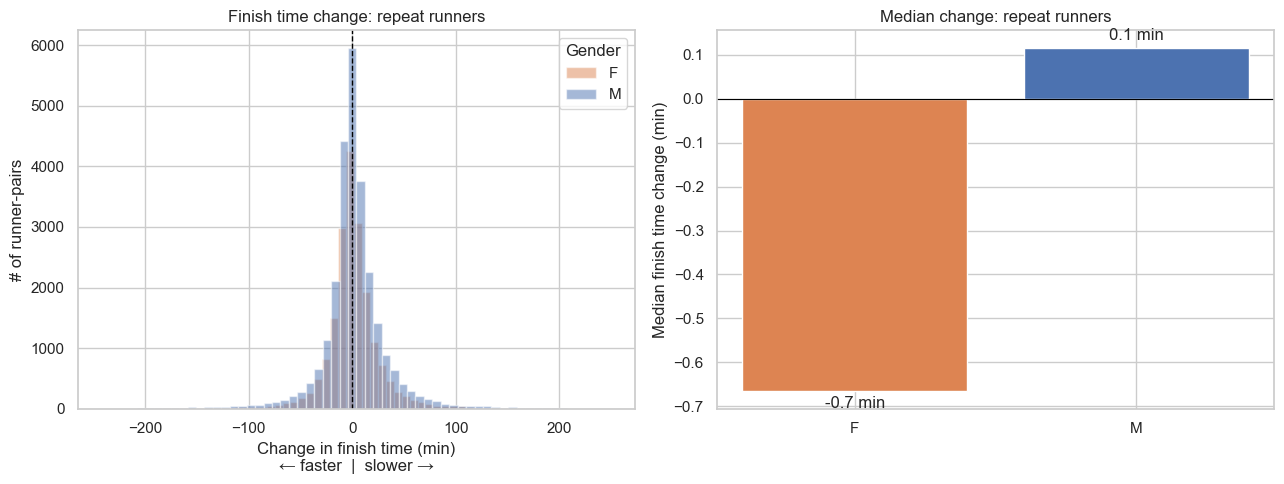

In [140]:
# ── 4a: Do repeat runners improve? ──────────────────────────────────────────
pct_improved = (pairs_df["finish_delta"] < 0).mean() * 100
print(f"{pct_improved:.1f}% of repeat-runner year-pairs show improvement")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of finish_delta
ax = axes[0]
for g, gdf in pairs_df.groupby("gender"):
    ax.hist(gdf["finish_delta"] / 60, bins=60, alpha=0.5, label=g, color=palette[g])
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Change in finish time (min)\n← faster  |  slower →")
ax.set_ylabel("# of runner-pairs")
ax.set_title("Finish time change: repeat runners")
ax.legend(title="Gender")

# Median improvement by gender
ax = axes[1]
med = pairs_df.groupby("gender")["finish_delta"].median() / 60
bars = ax.bar(med.index, med.values, color=[palette[g] for g in med.index])
ax.axhline(0, color="black", linewidth=0.8)
ax.bar_label(bars, fmt="%.1f min", padding=3)
ax.set_ylabel("Median finish time change (min)")
ax.set_title("Median change: repeat runners")

plt.tight_layout()
plt.show()

In [141]:
# ── 4b: Do repeat runners negative-split more on their second attempt? ───────
neg1 = pairs_df["neg_split1"].mean() * 100
neg2 = pairs_df["neg_split2"].mean() * 100
print(f"Negative-split rate: year1 = {neg1:.1f}%  →  year2 = {neg2:.1f}%")

# Conditional: among pairs where year1 was a positive split, what % flip to negative?
was_pos = pairs_df[pairs_df["split_diff1"] > THRESHOLD]
flip_rate = (was_pos["split_diff2"] < -THRESHOLD).mean() * 100
print(f"Of those who positive-split in year1, {flip_rate:.1f}% negative-split in year2")

# 2×2 table: neg_split year1 vs year2
ct = (
    pd.crosstab(
        pairs_df["neg_split1"].map({True: "Neg Y1", False: "Pos Y1"}),
        pairs_df["neg_split2"].map({True: "Neg Y2", False: "Pos Y2"}),
        normalize="index",
    ).round(3)
    * 100
)
print("\nSplit type transition (row = year1, col = year2, values = %):")
print(ct)

Negative-split rate: year1 = 5.1%  →  year2 = 5.2%
Of those who positive-split in year1, 4.3% negative-split in year2

Split type transition (row = year1, col = year2, values = %):
neg_split2  Neg Y2  Pos Y2
neg_split1                
Neg Y1        17.1    82.9
Pos Y1         4.6    95.4


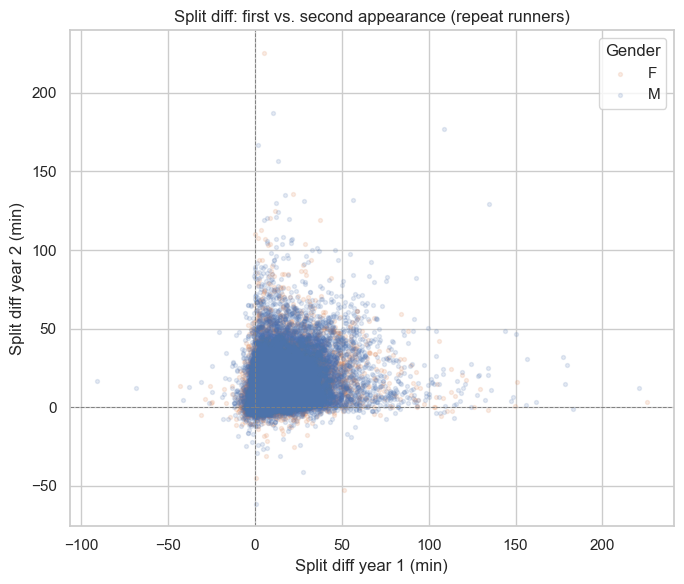

In [142]:
# Visualise split_diff change: year1 vs year2 scatter
fig, ax = plt.subplots(figsize=(7, 6))
for g, gdf in pairs_df.groupby("gender"):
    ax.scatter(
        gdf["split_diff1"] / 60,
        gdf["split_diff2"] / 60,
        alpha=0.15,
        s=8,
        color=palette[g],
        label=g,
    )
ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.7, linestyle="--")
ax.set_xlabel("Split diff year 1 (min)")
ax.set_ylabel("Split diff year 2 (min)")
ax.set_title("Split diff: first vs. second appearance (repeat runners)")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

---
## 5 · Sub-3 Women & Men's Equivalent

**Approach for the men's equivalent:**  
For each year, find the slowest woman who ran sub-3:00 — call her rank `R`.  
Then find the man at rank `R` and record his finish time.  
That man's time is the "men's equivalent of sub-3 for women" — i.e., running faster than this  
time puts a man in the same relative standing as a sub-3 woman.  
If this equivalent time is stable across years, the M/F performance gap is consistent.

In [143]:
SUB3 = 3 * 3600  # 10800 seconds
SUB235 = 2 * 3600 + 35 * 60  # 9300 seconds

results = []
for yr in YEARS:
    # Use df_full so runners without half splits are included in the count
    sub = df_full[df_full["year"] == yr]
    women = sub[sub["gender"] == "F"].sort_values("finish_secs")
    men = sub[sub["gender"] == "M"].sort_values("finish_secs")

    sub3_women = women[women["finish_secs"] < SUB3]
    if sub3_women.empty:
        continue

    n_sub3_women = len(sub3_women)
    n_sub235_men = len(men[men["finish_secs"] < SUB235])

    last_rank = n_sub3_women
    if last_rank <= len(men):
        mens_equiv_secs = men.iloc[last_rank - 1]["finish_secs"]
    else:
        mens_equiv_secs = np.nan

    results.append(
        {
            "year": yr,
            "n_sub3_women": n_sub3_women,
            "n_sub235_men": n_sub235_men,
            "last_sub3_women_time": sub3_women.iloc[-1]["finish_secs"],
            "mens_equiv_secs": mens_equiv_secs,
        }
    )

sub3_df = pd.DataFrame(results)
sub3_df["mens_equiv_fmt"] = sub3_df["mens_equiv_secs"].apply(
    lambda s: fmt_time(s) if pd.notna(s) else ""
)
print(sub3_df[["year", "n_sub3_women", "n_sub235_men", "mens_equiv_fmt"]])


   year  n_sub3_women  n_sub235_men mens_equiv_fmt
0  2018            75            49        2:36:40
1  2019           173           184        2:34:27
2  2021           153           144        2:35:29
3  2022           231           236        2:34:52
4  2023           272           291        2:34:23
5  2024           189           209        2:34:27
6  2025           385           396        2:34:45
7  2026           608           599        2:35:05


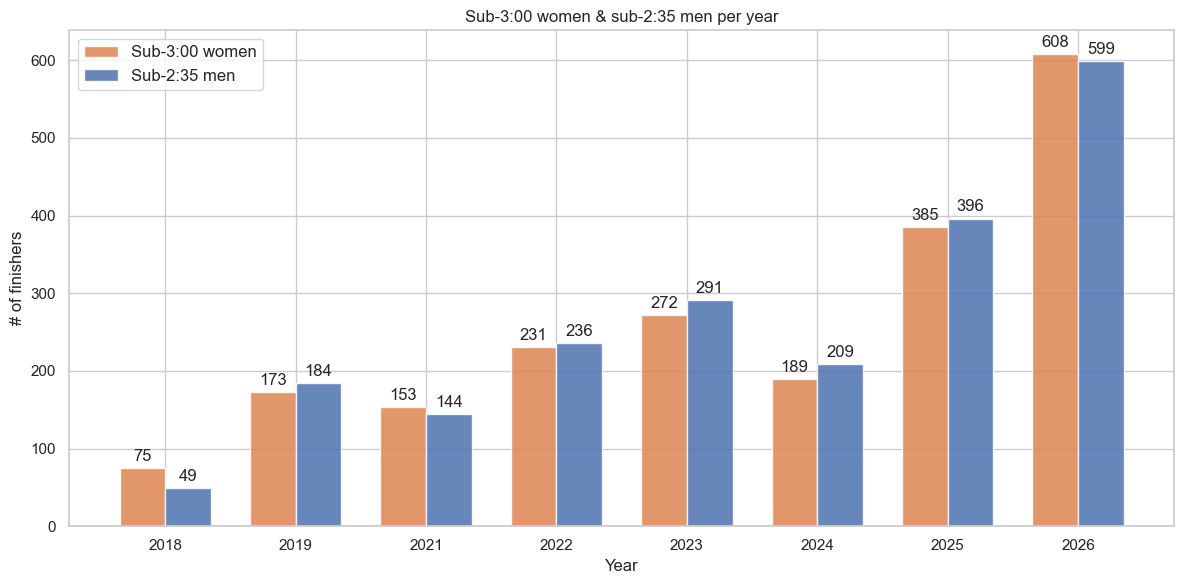

In [144]:
x = np.arange(len(sub3_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_f = ax.bar(
    x - width / 2,
    sub3_df["n_sub3_women"],
    width,
    color=palette["F"],
    alpha=0.85,
    label="Sub-3:00 women",
)
bars_m = ax.bar(
    x + width / 2,
    sub3_df["n_sub235_men"],
    width,
    color=palette["M"],
    alpha=0.85,
    label="Sub-2:35 men",
)

ax.bar_label(bars_f, padding=3, fontsize=12)
ax.bar_label(bars_m, padding=3, fontsize=12)

ax.set_xlabel("Year")
ax.set_ylabel("# of finishers")
ax.set_title("Sub-3:00 women & sub-2:35 men per year")
ax.set_xticks(x)
ax.set_xticklabels(sub3_df["year"])
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


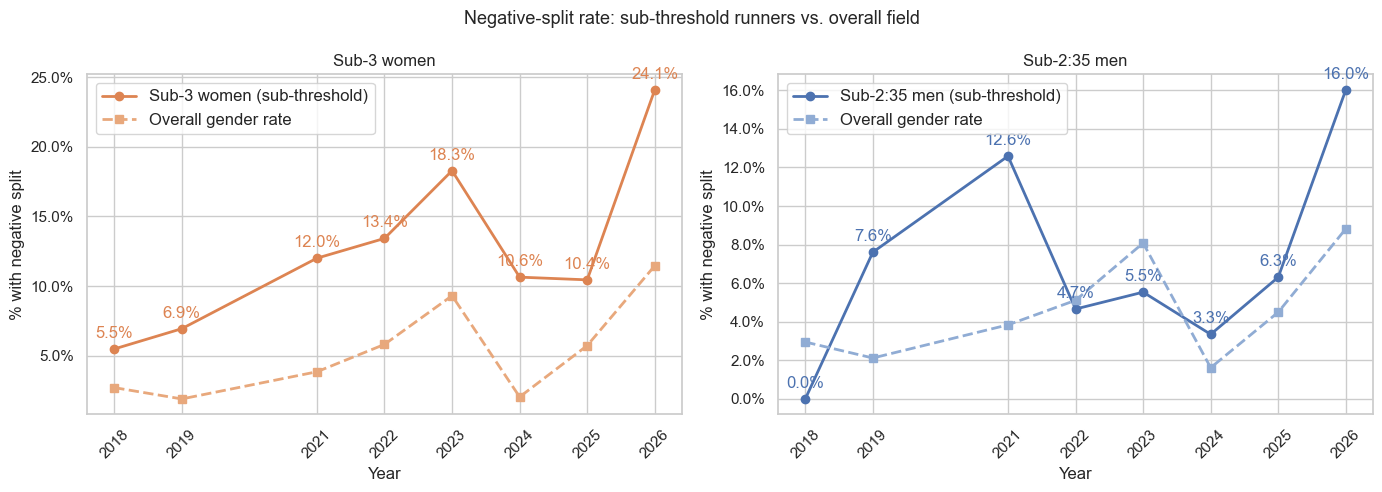

           neg_pct              overall_pct            
group Sub-2:35 men Sub-3 women Sub-2:35 men Sub-3 women
year                                                   
2018           0.0         5.5          3.0         2.7
2019           7.6         6.9          2.1         1.9
2021          12.6        12.0          3.8         3.8
2022           4.7        13.4          5.1         5.8
2023           5.5        18.3          8.1         9.3
2024           3.3        10.6          1.6         2.0
2025           6.3        10.4          4.5         5.7
2026          16.0        24.1          8.8        11.5


In [145]:
# Negative-split rate among sub-3 women and sub-2:35 men vs. the overall rate

threshold_runners = []
for yr in YEARS:
    yr_df = df[df["year"] == yr]
    women = yr_df[yr_df["gender"] == "F"]
    men = yr_df[yr_df["gender"] == "M"]

    sub3_women = women[women["finish_secs"] < SUB3]
    sub235_men = men[men["finish_secs"] < SUB235]

    for group, grp_df, label in [
        ("F", sub3_women, "Sub-3 women"),
        ("M", sub235_men, "Sub-2:35 men"),
    ]:
        if len(grp_df) == 0:
            continue
        neg_rate = (grp_df["split_diff"] < -THRESHOLD).mean() * 100
        # Overall rate for the same gender/year
        overall_rate = (
            yr_df[yr_df["gender"] == group]["split_diff"] < -THRESHOLD
        ).mean() * 100
        threshold_runners.append(
            {
                "year": yr,
                "group": label,
                "neg_pct": neg_rate,
                "overall_pct": overall_rate,
            }
        )

thr_df = pd.DataFrame(threshold_runners)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

colors = {"Sub-3 women": palette["F"], "Sub-2:35 men": palette["M"]}
overall_colors = {"Sub-3 women": "#e8a87c", "Sub-2:35 men": "#90acd4"}

for ax, group in zip(axes, ["Sub-3 women", "Sub-2:35 men"]):
    sub = thr_df[thr_df["group"] == group]
    ax.plot(
        sub["year"],
        sub["neg_pct"],
        marker="o",
        linewidth=2,
        color=colors[group],
        label=f"{group} (sub-threshold)",
    )
    ax.plot(
        sub["year"],
        sub["overall_pct"],
        marker="s",
        linewidth=2,
        linestyle="--",
        color=overall_colors[group],
        label="Overall gender rate",
    )

    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['neg_pct']:.1f}%",
            (row["year"], row["neg_pct"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=12,
            color=colors[group],
        )

    ax.set_title(group)
    ax.set_xlabel("Year")
    ax.set_ylabel("% with negative split")
    ax.set_xticks(YEARS)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=12)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

fig.suptitle(
    "Negative-split rate: sub-threshold runners vs. overall field", fontsize=13
)
plt.tight_layout()
plt.show()

print(
    thr_df.pivot_table(index="year", columns="group", values=["neg_pct", "overall_pct"])
    .round(1)
    .to_string()
)


---
## 6 · Age Group Breakdown of Sub-Threshold Runners

Age groups are inferred the same way as gender: within each `(year, gender, place_division)` group,
runners are sorted by finish time. The fastest is age group **A** (youngest/most competitive),
the next is **B**, and so on through **J** (10 groups total).

In [146]:
SUB3 = 3 * 3600
SUB235 = 2 * 3600 + 35 * 60

age_rows = []
for yr in YEARS:
    for gender, threshold in [("F", SUB3), ("M", SUB235)]:
        fast = df2[
            (df2["year"] == yr)
            & (df2["gender"] == gender)
            & (df2["finish_secs"] < threshold)
        ]
        if fast.empty:
            continue
        total = len(fast)
        for ag, ag_df in fast.groupby("age_group"):
            age_rows.append(
                {
                    "year": yr,
                    "gender": gender,
                    "age_group": ag,
                    "n": len(ag_df),
                    "pct": len(ag_df) / total * 100,
                }
            )

age_df = pd.DataFrame(age_rows)


def make_pivot(gender):
    sub = age_df[age_df["gender"] == gender]
    piv = sub.pivot_table(index="year", columns="age_group", values="n", fill_value=0)
    return piv.reindex(columns=sorted(piv.columns))


piv_f = make_pivot("F")
piv_m = make_pivot("M")
print("Sub-3:00 women by age group:")
print(piv_f)
print()
print("Sub-2:35 men by age group:")
print(piv_m)

Sub-3:00 women by age group:
age_group      A     B     C    D    E    F
year                                       
2018        68.0   3.0   2.0  0.0  0.0  0.0
2019       154.0  15.0   3.0  1.0  0.0  0.0
2021       126.0  18.0   3.0  2.0  1.0  0.0
2022       200.0  21.0   8.0  2.0  0.0  0.0
2023       224.0  36.0   7.0  1.0  0.0  0.0
2024       164.0  18.0   5.0  1.0  0.0  0.0
2025       331.0  32.0  15.0  3.0  1.0  1.0
2026       536.0  50.0  13.0  7.0  0.0  0.0

Sub-2:35 men by age group:
age_group      A     B     C    D
year                             
2018        47.0   2.0   0.0  0.0
2019       161.0  16.0   6.0  1.0
2021       132.0   9.0   2.0  0.0
2022       218.0  15.0   2.0  1.0
2023       252.0  29.0   5.0  3.0
2024       188.0  17.0   4.0  0.0
2025       349.0  36.0  11.0  0.0
2026       545.0  40.0  13.0  1.0


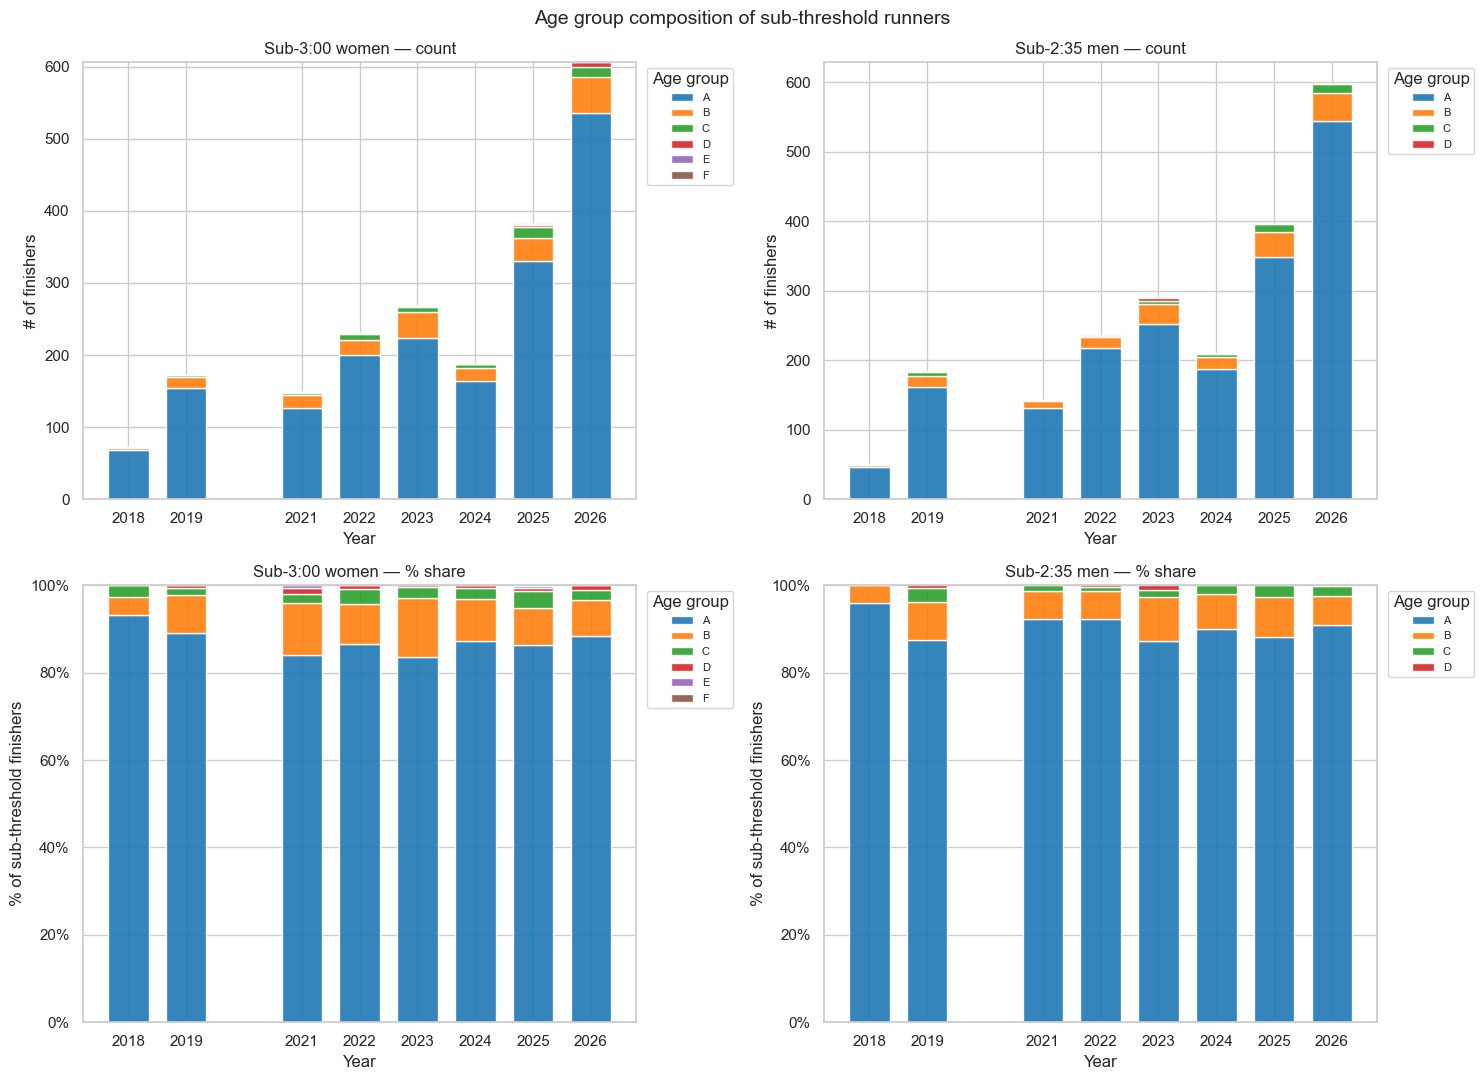

In [147]:
age_group_palette = sns.color_palette("tab10", n_colors=10)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for col, (piv, title_base) in enumerate(
    [
        (piv_f, "Sub-3:00 women"),
        (piv_m, "Sub-2:35 men"),
    ]
):
    piv_pct = piv.div(piv.sum(axis=1), axis=0) * 100

    # Top row: raw counts
    ax = axes[0][col]
    bottom = np.zeros(len(piv))
    for i, ag in enumerate(piv.columns):
        ax.bar(
            piv.index,
            piv[ag].values,
            bottom=bottom,
            label=ag,
            color=age_group_palette[i],
            alpha=0.9,
            width=0.7,
        )
        bottom += piv[ag].values
    ax.set_title(f"{title_base} — count", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("# of finishers")
    ax.set_xticks(piv.index)
    ax.legend(title="Age group", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

    # Bottom row: % share
    ax = axes[1][col]
    bottom = np.zeros(len(piv_pct))
    for i, ag in enumerate(piv_pct.columns):
        ax.bar(
            piv_pct.index,
            piv_pct[ag].values,
            bottom=bottom,
            label=ag,
            color=age_group_palette[i],
            alpha=0.9,
            width=0.7,
        )
        bottom += piv_pct[ag].values
    ax.set_title(f"{title_base} — % share", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("% of sub-threshold finishers")
    ax.set_xticks(piv_pct.index)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(title="Age group", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig.suptitle("Age group composition of sub-threshold runners", fontsize=14)
plt.tight_layout()
plt.show()

---
## 7 · Overall Field Performance Trends

How has the field changed year-over-year in size and speed?

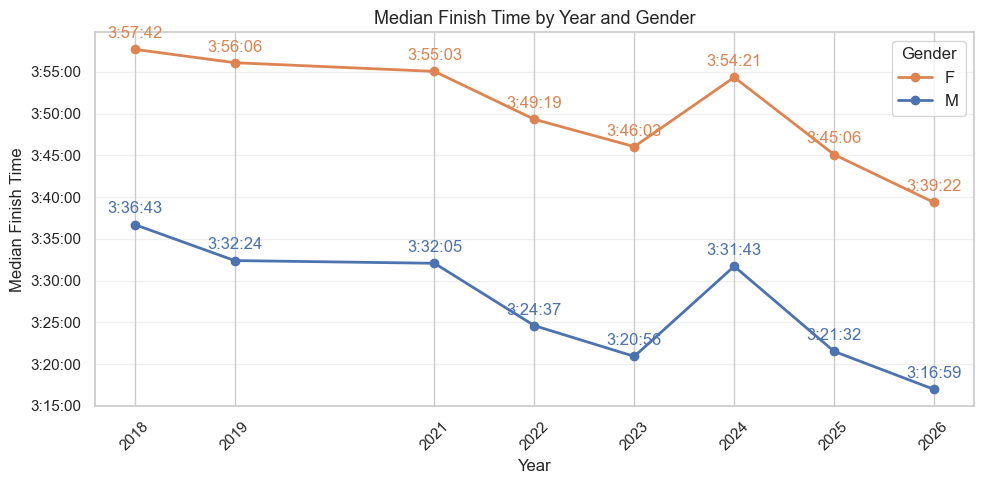

Median finish time by year and gender:
gender        F        M
year                    
2018    3:57:42  3:36:43
2019    3:56:06  3:32:24
2021    3:55:03  3:32:05
2022    3:49:19  3:24:37
2023    3:46:03  3:20:56
2024    3:54:21  3:31:43
2025    3:45:06  3:21:32
2026    3:39:22  3:16:59


In [ ]:
med = (
    df_full.groupby(["year", "gender"])["finish_secs"]
    .median()
    .reset_index(name="median_secs")
)

fig, ax = plt.subplots(figsize=(10, 5))

for gender, grp in med.groupby("gender"):
    ax.plot(
        grp["year"],
        grp["median_secs"] / 60,
        marker="o",
        color=palette[gender],
        label=gender,
        linewidth=2,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            fmt_time(row["median_secs"]),
            (row["year"], row["median_secs"] / 60),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=12,
            color=palette[gender],
        )

ax.set_title("Median Finish Time by Year and Gender", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Median Finish Time")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_time(x * 60)))
ax.legend(title="Gender", fontsize=12)
ax.set_xticks(YEARS)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

print("Median finish time by year and gender:")
print(med.pivot(index="year", columns="gender", values="median_secs").map(fmt_time))


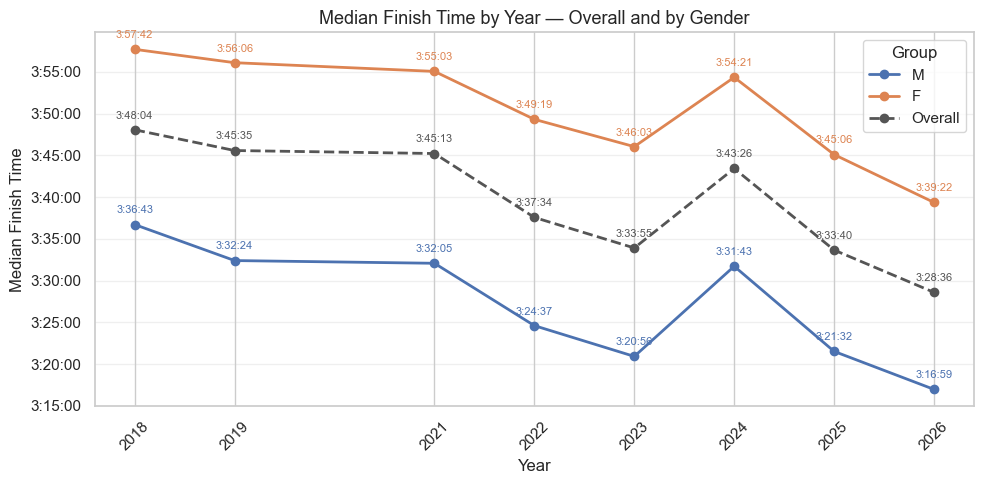

            F        M  Overall
year                           
2018  3:57:42  3:36:43  3:48:04
2019  3:56:06  3:32:24  3:45:35
2021  3:55:03  3:32:05  3:45:13
2022  3:49:19  3:24:37  3:37:34
2023  3:46:03  3:20:56  3:33:55
2024  3:54:21  3:31:43  3:43:26
2025  3:45:06  3:21:32  3:33:40
2026  3:39:22  3:16:59  3:28:36


In [ ]:
# Overall (all-runner) median alongside M/F, using df_full so no half-split filter
med_g = (
    df_full.groupby(["year", "gender"])["finish_secs"]
    .median()
    .reset_index(name="median_secs")
)
med_all = (
    df_full.groupby("year")["finish_secs"].median().reset_index(name="median_secs")
)
med_all["gender"] = "Overall"

fig, ax = plt.subplots(figsize=(10, 5))

line_styles = {
    "M": (palette["M"], "-"),
    "F": (palette["F"], "-"),
    "Overall": ("#555555", "--"),
}

for label, grp in [(g, med_g[med_g["gender"] == g]) for g in ["M", "F"]] + [
    ("Overall", med_all)
]:
    color, ls = line_styles[label]
    ax.plot(
        grp["year"],
        grp["median_secs"] / 60,
        marker="o",
        color=color,
        linestyle=ls,
        label=label,
        linewidth=2,
    )
    for _, row in grp.iterrows():
        ax.annotate(
            fmt_time(row["median_secs"]),
            (row["year"], row["median_secs"] / 60),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
            color=color,
        )

ax.set_title("Median Finish Time by Year — Overall and by Gender", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Median Finish Time")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: fmt_time(x * 60)))
ax.legend(title="Group", fontsize=11)
ax.set_xticks(YEARS)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

tbl = med_g.pivot(index="year", columns="gender", values="median_secs").join(
    med_all.set_index("year")["median_secs"].rename("Overall")
)
print(tbl.map(fmt_time))
